# EDA

The data is simulated. It represents two daily flights from Edinburgh and Glasgow to Dubai over the course of 2 years. The object of this notebook is to begin to understand the data set. The goal is to understand how different factors included in the data influence the number of Child Meals (CHML) are ordered per day on both flights.

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw_data.csv', parse_dates=['Flight_Date'])

# Basic shape and types
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head())
print(df.describe())

Shape: (1462, 11)
Unnamed: 0                           int64
Flight_Date                 datetime64[ns]
Route                               object
Carrier                             object
Scheduled_Departure_Time            object
Aircraft_Capacity                    int64
Actual_Pax_Count                     int64
Is_Weekend                            bool
Is_Holiday_Period                     bool
CHML_Ordered                         int64
Flight_ID                           object
dtype: object
   Unnamed: 0 Flight_Date    Route   Carrier Scheduled_Departure_Time  \
0           0  2024-01-01  EDI-DXB  Emirates      2024-01-01 14:00:00   
1           1  2024-01-01  GLA-DXB  Emirates      2024-01-01 20:00:00   
2           2  2024-01-02  EDI-DXB  Emirates      2024-01-02 14:00:00   
3           3  2024-01-02  GLA-DXB  Emirates      2024-01-02 20:00:00   
4           4  2024-01-03  EDI-DXB  Emirates      2024-01-03 14:00:00   

   Aircraft_Capacity  Actual_Pax_Count  Is_Weekend  Is_H

In [2]:
print(len(df)/2, "days of data")

731.0 days of data


In [3]:
#look at missing values

print(df.isnull().sum())

Unnamed: 0                  0
Flight_Date                 0
Route                       0
Carrier                     0
Scheduled_Departure_Time    0
Aircraft_Capacity           0
Actual_Pax_Count            0
Is_Weekend                  0
Is_Holiday_Period           0
CHML_Ordered                0
Flight_ID                   0
dtype: int64


* The data consists of 11 columns and 1462 lines. Consisting of two years of SPML data for two different routes.
* No missing data
* All data types are correct

In [4]:
# Drop the old index column from data 

df.drop('Unnamed: 0', axis=1, inplace =True)

## Target Variable

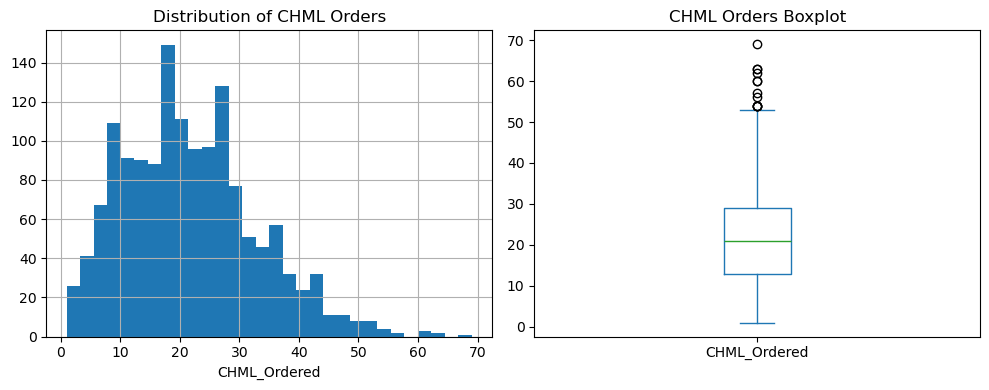

count    1462.00000
mean       21.74829
std        11.20579
min         1.00000
25%        13.00000
50%        21.00000
75%        29.00000
max        69.00000
Name: CHML_Ordered, dtype: float64
Skewness: 0.62


In [5]:
# Distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['CHML_Ordered'].hist(bins=30)
plt.title('Distribution of CHML Orders')
plt.xlabel('CHML_Ordered')

plt.subplot(1, 2, 2)
df['CHML_Ordered'].plot(kind='box')
plt.title('CHML Orders Boxplot')
plt.tight_layout()
plt.show()

# Stats
print(df['CHML_Ordered'].describe())
print(f"Skewness: {df['CHML_Ordered'].skew():.2f}")

The range of values is from 0 to 63. The distribution of CHML orders is positively skewed and looks like a poisson distributuion.

All outliers are Glasgow to Dubai flights and all take place during a holiday period

## Categorical Breakdowns

In [6]:
df.groupby('Route')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max', 'count'])

,mean,std,min,max,count
Route,,,,,
EDI-DXB,18.031464,9.587397,1,46,731
GLA-DXB,25.465116,11.477188,2,69,731


The average number of child meals ordered is higher in Glasgow. This would make sense as it is a larger plane

In [7]:
df.groupby('Is_Holiday_Period')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
Is_Holiday_Period,,,,
False,18.275401,8.634511,1,45
True,33.208824,11.089895,8,69


The number of CHML meals ordered is much higher during Schools holidays

In [8]:
df.groupby('Is_Weekend')['CHML_Ordered'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
Is_Weekend,,,,
False,21.661568,11.340413,1,69
True,21.966346,10.870268,1,60


Whether it is the Weekend or not seems to have little impact on the number of child meals being ordered

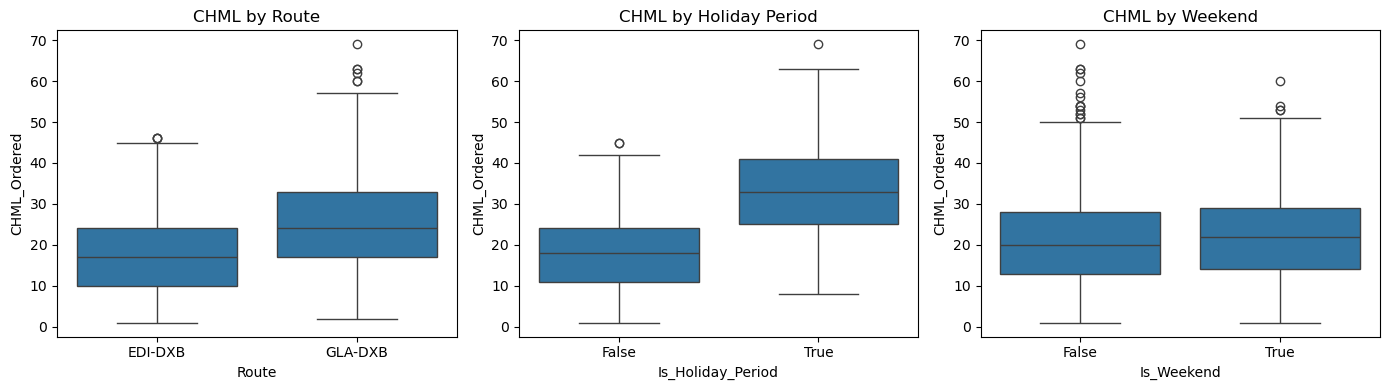

In [9]:
#Visualising the above
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, x='Route', y='CHML_Ordered', ax=axes[0])
axes[0].set_title('CHML by Route')

sns.boxplot(data=df, x='Is_Holiday_Period', y='CHML_Ordered', ax=axes[1])
axes[1].set_title('CHML by Holiday Period')

sns.boxplot(data=df, x='Is_Weekend', y='CHML_Ordered', ax=axes[2])
axes[2].set_title('CHML by Weekend')

plt.tight_layout()
plt.show()

## Time Series

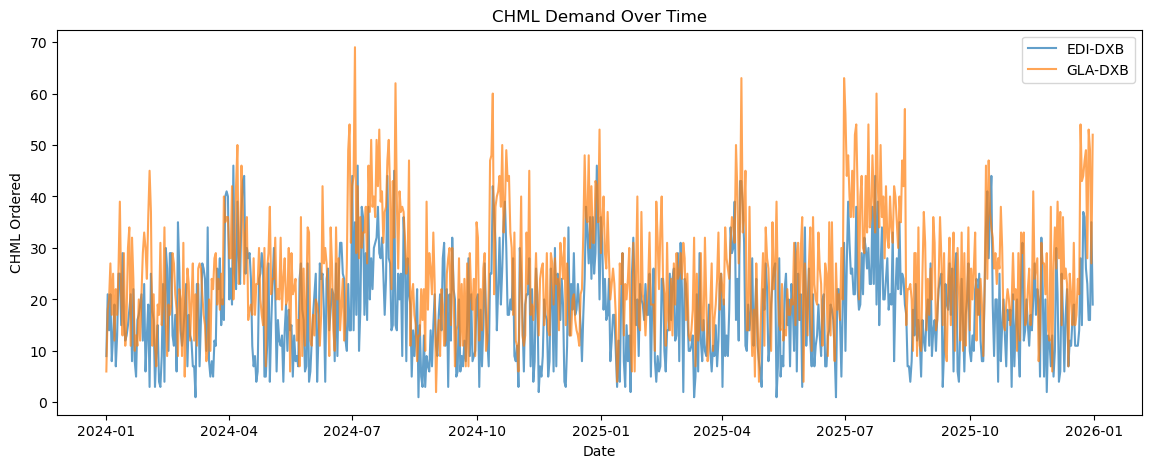

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

for route in df['Route'].unique():
    route_data = df[df['Route'] == route]
    ax.plot(route_data['Flight_Date'], route_data['CHML_Ordered'], 
            label=route, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('CHML Ordered')
ax.set_title('CHML Demand Over Time')
ax.legend()
plt.show()

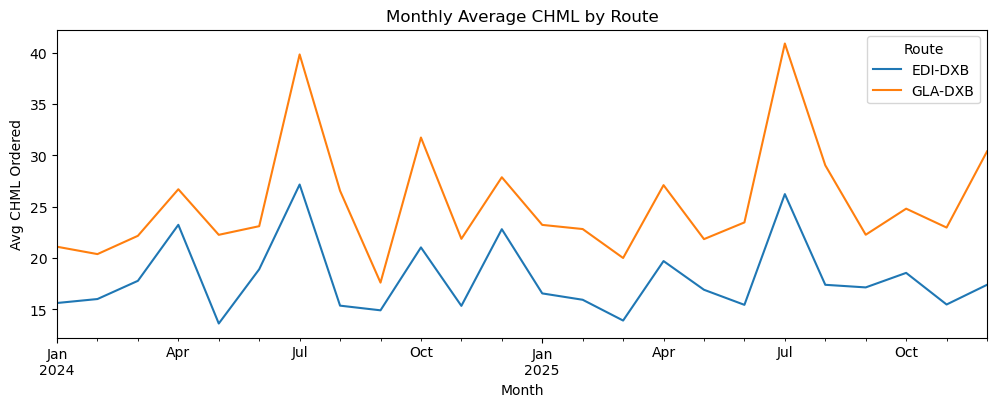

In [11]:
df['Month'] = df['Flight_Date'].dt.to_period('M')
monthly = df.groupby(['Month', 'Route'])['CHML_Ordered'].mean().unstack()
monthly.plot(figsize=(12, 4), title='Monthly Average CHML by Route')
plt.ylabel('Avg CHML Ordered')
plt.show()

Months with long holidays have higher averages. Glasgow always sells more CHMLS than Edinburgh. Peaks in both figures align with school holidays.

## Correlations

                   Aircraft_Capacity  Actual_Pax_Count  CHML_Ordered
Aircraft_Capacity           1.000000          0.989376      0.331802
Actual_Pax_Count            0.989376          1.000000      0.325905
CHML_Ordered                0.331802          0.325905      1.000000


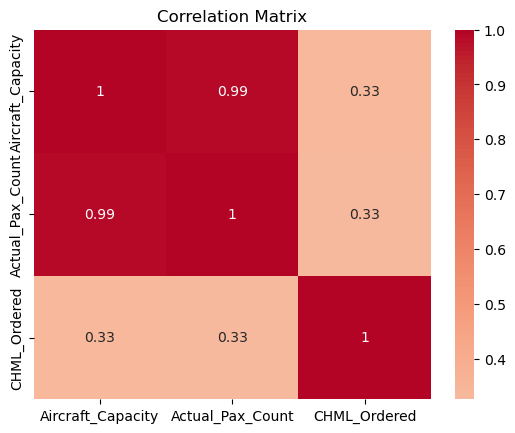

In [12]:
numeric_cols = ['Aircraft_Capacity', 'Actual_Pax_Count', 'CHML_Ordered']
corr = df[numeric_cols].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

Aircraft capacity and actual pax counts are slighty correlated with CHML Order numbers.

## Feature Interactions

Route                EDI-DXB    GLA-DXB
Is_Holiday_Period                      
False              15.272727  21.278075
True               27.135294  39.282353


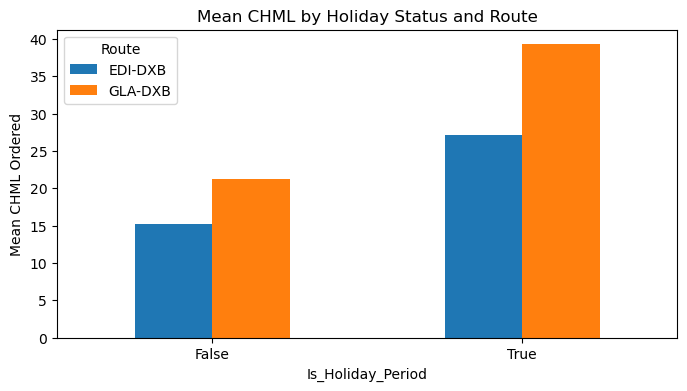

In [13]:
# Holiday + Route interaction
holiday_route = df.groupby(['Is_Holiday_Period', 'Route'])['CHML_Ordered'].mean().unstack()
print(holiday_route)

# Visualise
holiday_route.plot(kind='bar', figsize=(8, 4))
plt.title('Mean CHML by Holiday Status and Route')
plt.ylabel('Mean CHML Ordered')
plt.xticks(rotation=0)
plt.show()

Holiday factor looks to have equal effect for both routes

In [14]:
print(df.columns)

Index(['Flight_Date', 'Route', 'Carrier', 'Scheduled_Departure_Time',
       'Aircraft_Capacity', 'Actual_Pax_Count', 'Is_Weekend',
       'Is_Holiday_Period', 'CHML_Ordered', 'Flight_ID', 'Month'],
      dtype='object')


In [15]:
df.to_csv('data/data.csv')

## Conclusion

Flight Date seems to affect CHML order numbers if the date falls on a holiday. The Glasgow flight has a higher number of meals ordered but this likely because of the larger aircraft. The carrier has no bearing on the target variable as both flights are operated by the same airline. Is_weekend can also be dropped from the model as it looks like it has not effect on the number of CHML ordered.